# HP01 spectral partitioning — quick start

This notebook loads a wave spectra file, runs the Hanson & Phillips (2001)
partitioning with and without spectral smoothing, and does a first-pass
evaluation of the results.

Run each cell with **Shift+Enter**, top to bottom.

The example uses a small WAVEWATCH III output file from the wavespectra test
suite (2 sites, 9 time steps). To work with your own data, only the reading
cell changes — everything downstream is identical. wavespectra has readers for
most common formats (`read_ndbc`, `read_datawell`, `read_swan`,
`read_triaxys`, ...): see the
[documentation](https://wavespectra.readthedocs.io/en/latest/input.html).

In [1]:
import matplotlib.pyplot as plt
import wavespectra

# Opt in to the upcoming wavespectra 5.0 behaviour, where partitioning
# returns a full dataset (spectra + winds + depth) rather than spectra alone
wavespectra.set_options(dataset_transforms=True)

print(wavespectra.__version__)  # needs 4.6.0 or newer for the new HP01 code

4.7.0


## 1. Get the sample data file

This cell downloads the sample file (~50 kB) into the notebook folder. It only
needs to run once — if the download is blocked by a proxy, download the file in
your browser from the URL below and save it next to this notebook instead.

In [2]:
import urllib.request

url = (
    "https://github.com/wavespectra/wavespectra/raw/main/tests/sample_files/ww3file.nc"
)
urllib.request.urlretrieve(url, "ww3file.nc")

('ww3file.nc', <http.client.HTTPMessage at 0x70e02498b410>)

## 2. Read the spectra

`read_ww3` returns an `xarray.Dataset` — think of it as a MATLAB struct whose
arrays carry named, labelled dimensions. The spectral variable is always called
`efth`: the energy density $E(f,\theta)$ in m²/Hz/degree, here with dimensions
`(time, site, freq, dir)`. This file also carries wind speed (`wspd`), wind
direction (`wdir`) and depth (`dpt`), which the partitioning uses to identify
the wind sea.

In [3]:
dset = wavespectra.read_ww3("ww3file.nc").load()
dset

<xarray.Dataset> Size: 44kB
Dimensions:  (time: 9, site: 2, freq: 25, dir: 24)
Coordinates:
  * time     (time) datetime64[ns] 72B 2014-12-01 ... 2014-12-05
  * site     (site) int32 8B 1 2
  * freq     (freq) float32 100B 0.04118 0.0453 0.04983 ... 0.3352 0.3687 0.4056
  * dir      (dir) float32 96B 270.0 255.0 240.0 225.0 ... 315.0 300.0 285.0
Data variables:
    dpt      (time, site) float32 72B 106.6 818.7 106.6 ... 818.7 106.6 818.7
    efth     (time, site, freq, dir) float32 43kB 5.596e-17 ... 9.287e-06
    lat      (site) float32 8B 19.95 19.8
    lon      (site) float32 8B 92.1 92.0
    wspd     (time, site) float32 72B 5.1 5.478 6.149 5.787 ... 4.2 3.27 2.89
    wdir     (time, site) float32 72B 24.92 21.98 331.1 ... 341.8 30.44 25.41

## 3. A first look

All wavespectra functionality hangs off the `.spec` attribute of the dataset.
Integrated parameters (`hs`, `tp`, `dpm`, ...) and plotting are one-liners.

In [4]:
hs_total = dset.spec.hs()
hs_total.to_dataframe("hs")

hs
time                site          
2014-12-01 00:00:00 1     0.755239
                    2     0.801251
2014-12-01 12:00:00 1     0.875578
                    2     0.866653
2014-12-02 00:00:00 1     0.785535
                    2     0.789522
2014-12-02 12:00:00 1     0.742789
                    2     0.749590
2014-12-03 00:00:00 1     0.722384
                    2     0.819651
2014-12-03 12:00:00 1     0.765646
                    2     0.757760
2014-12-04 00:00:00 1     0.697398
                    2     0.714135
2014-12-04 12:00:00 1     0.658290
                    2     0.682964
2014-12-05 00:00:00 1     0.717262
                    2     0.795536

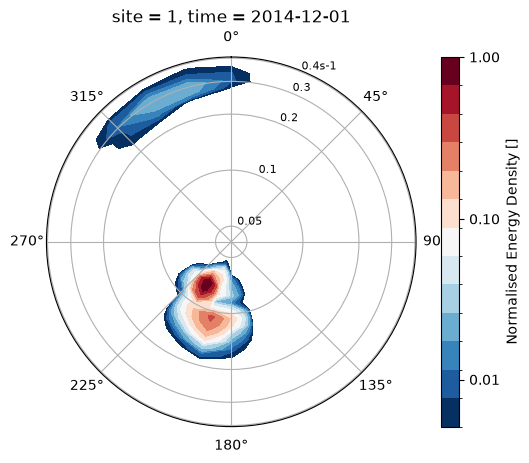

In [5]:
# Polar plot of the first spectrum (site 1, first time step)
dset.isel(time=0, site=0).spec.plot()

## 4. Run HP01 — without and with smoothing

`hp01` first partitions the spectrum with the watershed algorithm and merges
the wind-sea components (as in the standard WW3 PTM1 method), then combines
adjacent swell partitions following the criteria of Hanson & Phillips (2001)
and Hanson et al. (2009). The wind speed, wind direction and depth are taken
from the dataset automatically.

The `smooth` flag controls whether the watershed runs on a smoothed copy of
the spectrum. On clean model spectra like this file it makes little
difference; on noisy **measured** spectra it typically prevents spurious small
partitions.

The result is the same dataset with one extra dimension, `part`: partition 0
is the wind sea, partitions 1, 2, ... are the swells sorted by energy. Other
tuning knobs (merging thresholds `kappa`, `zeta`, `angle_max`, noise floor,
`hs_min`) are described in the docstring — run
`help(dset.spec.partition.hp01)` to see it.

In [6]:
parts_raw = dset.spec.partition.hp01(smooth=False)
parts_smooth = dset.spec.partition.hp01(smooth=True)
parts_raw

<xarray.Dataset> Size: 173kB
Dimensions:  (freq: 25, site: 2, time: 9, dir: 24, part: 4)
Coordinates:
  * freq     (freq) float32 100B 0.04118 0.0453 0.04983 ... 0.3352 0.3687 0.4056
  * site     (site) int32 8B 1 2
  * time     (time) datetime64[ns] 72B 2014-12-01 ... 2014-12-05
  * dir      (dir) float32 96B 270.0 255.0 240.0 225.0 ... 315.0 300.0 285.0
  * part     (part) int64 32B 0 1 2 3
Data variables:
    efth     (part, time, site, freq, dir) float32 173kB 0.0 0.0 0.0 ... 0.0 0.0
    dpt      (time, site) float32 72B 106.6 818.7 106.6 ... 818.7 106.6 818.7
    lat      (site) float32 8B 19.95 19.8
    lon      (site) float32 8B 92.1 92.0
    wspd     (time, site) float32 72B 5.1 5.478 6.149 5.787 ... 4.2 3.27 2.89
    wdir     (time, site) float32 72B 24.92 21.98 331.1 ... 341.8 30.44 25.41

## 5. Evaluate the results

### 5.1 Integrated parameters per partition

`spec.stats` computes any set of integrated parameters, here for every
partition at every time and site. Empty partitions come out as NaN and are
dropped from the table.

In [7]:
stats_raw = parts_raw.spec.stats(["hs", "tp", "dpm"])
stats_smooth = parts_smooth.spec.stats(["hs", "tp", "dpm"])
stats_raw.to_dataframe().dropna().round(2)

hs     tp         dpm
site time                part                         
1    2014-12-01 00:00:00 0     0.31   3.31  334.459991
                         1     0.50  13.24  209.210007
                         2     0.47   9.11  195.050003
     2014-12-01 12:00:00 0     0.52   2.99  327.029999
                         1     0.54  12.61  208.990005
                         2     0.45   8.98  196.100006
     2014-12-02 00:00:00 0     0.32   2.78  340.679993
                         1     0.57  12.57  209.130005
                         2     0.43   8.26  202.289993
     2014-12-02 12:00:00 0     0.28   2.65  337.480011
                         1     0.58  12.51  206.369995
                         2     0.36   7.75  206.149994
     2014-12-03 00:00:00 0     0.24   2.65  341.089996
                         1     0.61  13.22  199.160004
                         2     0.29   7.60  201.339996
     2014-12-03 12:00:00 0     0.40   2.65  333.529999
                         1     0.65  12.46  202.059998
     2014-12-04 00:00:00 0     0.24   2.95  341.850006
                         1     0.65  12.28  200.110001
     2014-12-04 12:00:00 0     0.17   2.64  343.429993
                         1     0.56  11.59  202.130005
                         2     0.30  15.15  205.080002
     2014-12-05 00:00:00 1     0.55  11.31  200.720001
                         2     0.46  14.85  204.619995
2    2014-12-01 00:00:00 0     0.36   3.40  341.570007
                         1     0.53  13.28  209.220001
                         2     0.48   9.12  194.539993
     2014-12-01 12:00:00 0     0.47   2.96  343.309998
                         1     0.73  12.62  209.059998
     2014-12-02 00:00:00 0     0.27   2.98  354.200012
                         1     0.60  12.61  209.110001
                         2     0.43   8.21  201.669998
     2014-12-02 12:00:00 0     0.23   2.64  342.410004
                         1     0.61  12.58  206.220001
                         2     0.37   7.74  205.559998
     2014-12-03 00:00:00 0     0.41   2.91  359.079987
                         1     0.64  13.25  199.039993
                         2     0.30   7.61  200.179993
     2014-12-03 12:00:00 0     0.33   2.65  337.880005
                         1     0.68  12.48  201.889999
     2014-12-04 00:00:00 0     0.22   3.02  350.299988
                         1     0.68  12.28  199.949997
     2014-12-04 12:00:00 0     0.15   2.64  349.649994
                         1     0.58  11.59  201.970001
                         2     0.33  15.14  205.160004
     2014-12-05 00:00:00 0     0.32   2.68  349.350006
                         1     0.53  14.83  204.389999
                         2     0.50  11.22  200.580002

### 5.2 Number of partitions found

A simple but telling comparison: how many non-empty partitions does each
spectrum produce with and without smoothing? On noisy measured spectra, the
raw (unsmoothed) count is typically higher.

In [8]:
n_raw = parts_raw.spec.hs().notnull().sum("part").rename("n_raw")
n_smooth = parts_smooth.spec.hs().notnull().sum("part").rename("n_smooth")
n_raw.to_dataframe().join(n_smooth.to_dataframe())

n_raw  n_smooth
time                site                 
2014-12-01 00:00:00 1         4         4
                    2         4         4
2014-12-01 12:00:00 1         4         4
                    2         4         4
2014-12-02 00:00:00 1         4         4
                    2         4         4
2014-12-02 12:00:00 1         4         4
                    2         4         4
2014-12-03 00:00:00 1         4         4
                    2         4         4
2014-12-03 12:00:00 1         4         4
                    2         4         4
2014-12-04 00:00:00 1         4         4
                    2         4         4
2014-12-04 12:00:00 1         4         4
                    2         4         4
2014-12-05 00:00:00 1         4         4
                    2         4         4

### 5.3 Energy conservation check

Partitioning only splits the spectrum — no energy should be created or lost.
The partition wave heights must therefore satisfy
$H_{s,total} = \sqrt{\sum_i H_{s,i}^2}$. The difference below should be at
numerical precision (~1e-7).

In [9]:
hs_from_parts = (parts_raw.spec.hs() ** 2).sum("part") ** 0.5
print("max |Hs difference|:", float(abs(hs_from_parts - hs_total).max()))

max |Hs difference|: 1.1920928955078125e-07


### 5.4 Visual check — the partitioned spectra

One panel per partition, for a single spectrum. This is the plot to stare at
when judging whether the partitions correspond to physically distinct wave
systems. Change `time=0, site=0` (or swap `parts_raw` for `parts_smooth`) to
inspect others.

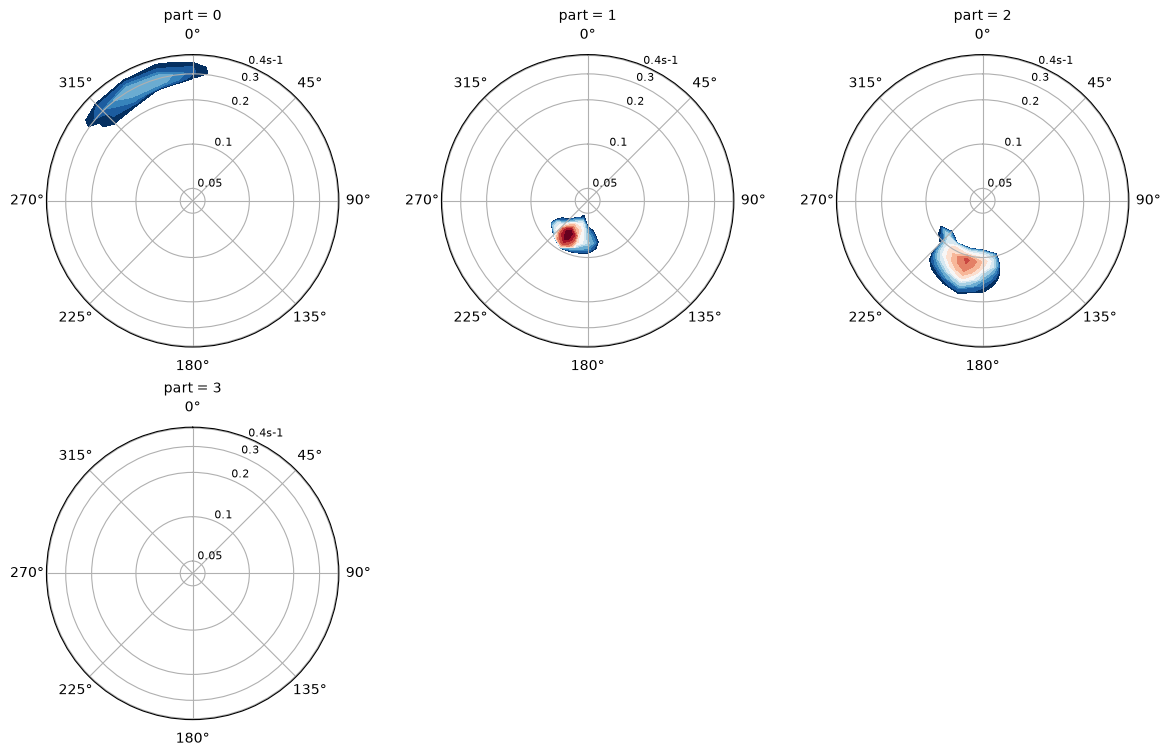

In [10]:
parts_raw.isel(time=0, site=0).spec.plot(
    col="part", col_wrap=3, add_colorbar=False, figsize=(12, 8)
)

## 6. Fixing the number of partitions

By default HP01 keeps as many swell partitions as the combining criteria
leave. Often it is more practical to work with a fixed, pre-defined number of
partitions — for consistent output tables, or to compare against another
method that produces a set number of systems.

The `swells` argument does this: the strongest `swells` swell systems are
kept, and any remaining smaller swells are **merged with their closest
neighbour** (rather than discarded), so total energy is preserved. To drop
the extra swells instead, pass `combine_extra_swells=False`. Below we shrink
each spectrum to exactly 3 partitions: the wind sea plus 2 swells.

In [11]:
parts_fixed = dset.spec.partition.hp01(smooth=False, swells=2)
stats_fixed = parts_fixed.spec.stats(["hs", "tp", "dpm"])
stats_fixed.to_dataframe().dropna().round(2)

hs     tp         dpm
site time                part                         
1    2014-12-01 00:00:00 0     0.31   3.31  334.459991
                         1     0.50  13.24  209.210007
                         2     0.47   9.11  195.050003
     2014-12-01 12:00:00 0     0.52   2.99  327.029999
                         1     0.54  12.61  208.990005
                         2     0.45   8.98  196.100006
     2014-12-02 00:00:00 0     0.32   2.78  340.679993
                         1     0.57  12.57  209.130005
                         2     0.43   8.26  202.289993
     2014-12-02 12:00:00 0     0.28   2.65  337.480011
                         1     0.58  12.51  206.369995
                         2     0.36   7.75  206.149994
     2014-12-03 00:00:00 0     0.24   2.65  341.089996
                         1     0.61  13.22  199.160004
                         2     0.29   7.60  201.339996
     2014-12-03 12:00:00 0     0.40   2.65  333.529999
                         1     0.65  12.46  202.059998
     2014-12-04 00:00:00 0     0.24   2.95  341.850006
                         1     0.65  12.28  200.110001
     2014-12-04 12:00:00 0     0.17   2.64  343.429993
                         1     0.56  11.59  202.130005
                         2     0.30  15.15  205.080002
     2014-12-05 00:00:00 1     0.55  11.31  200.720001
                         2     0.46  14.85  204.619995
2    2014-12-01 00:00:00 0     0.36   3.40  341.570007
                         1     0.53  13.28  209.220001
                         2     0.48   9.12  194.539993
     2014-12-01 12:00:00 0     0.47   2.96  343.309998
                         1     0.73  12.62  209.059998
     2014-12-02 00:00:00 0     0.27   2.98  354.200012
                         1     0.60  12.61  209.110001
                         2     0.43   8.21  201.669998
     2014-12-02 12:00:00 0     0.23   2.64  342.410004
                         1     0.61  12.58  206.220001
                         2     0.37   7.74  205.559998
     2014-12-03 00:00:00 0     0.41   2.91  359.079987
                         1     0.64  13.25  199.039993
                         2     0.30   7.61  200.179993
     2014-12-03 12:00:00 0     0.33   2.65  337.880005
                         1     0.68  12.48  201.889999
     2014-12-04 00:00:00 0     0.22   3.02  350.299988
                         1     0.68  12.28  199.949997
     2014-12-04 12:00:00 0     0.15   2.64  349.649994
                         1     0.58  11.59  201.970001
                         2     0.33  15.14  205.160004
     2014-12-05 00:00:00 0     0.32   2.68  349.350006
                         1     0.53  14.83  204.389999
                         2     0.50  11.22  200.580002

In [12]:
# Energy is still conserved after merging the extra swells
hs_from_fixed = (parts_fixed.spec.hs() ** 2).sum("part") ** 0.5
print("max |Hs difference|:", float(abs(hs_from_fixed - hs_total).max()))

max |Hs difference|: 1.1920928955078125e-07


### 6.1 Time series per partition

Hs of each fixed partition through time — a convenient view for following the
evolution of the individual wave systems.

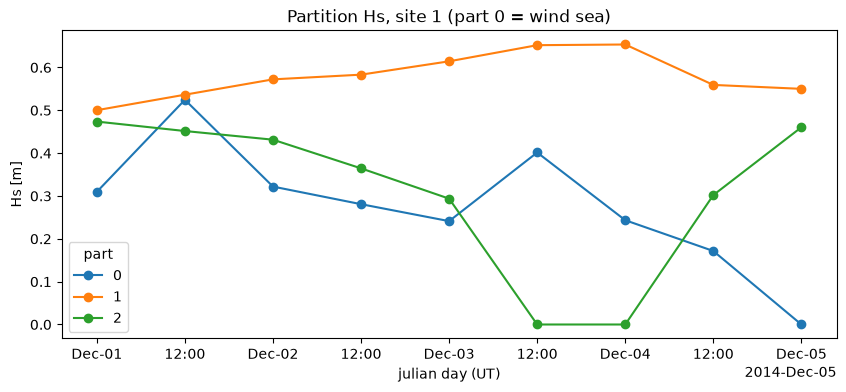

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
stats_fixed.hs.isel(site=0).plot.line(x="time", ax=ax, marker="o")
ax.set_ylabel("Hs [m]")
ax.set_title("Partition Hs, site 1 (part 0 = wind sea)")
plt.show()

## Next steps

- Point section 2 at a real observations file (e.g. `wavespectra.read_ndbc`,
  `read_datawell`, ...) and rerun everything below unchanged.
- Compare the raw, smoothed and fixed-number runs partition by partition
  against reference results for the same spectra.
- The full partitioning documentation, including the meaning of every HP01
  parameter, is at
  <https://wavespectra.readthedocs.io/en/latest/partitioning.html>.